In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

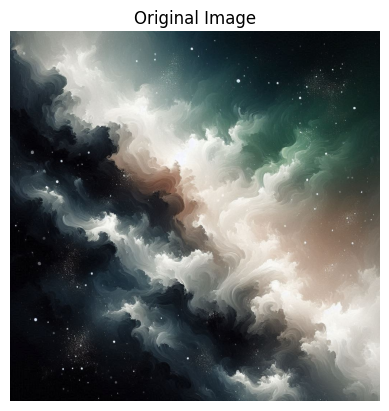

In [ ]:

image = Image.open("/content/drive/MyDrive/hello.png")


image.show()


plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

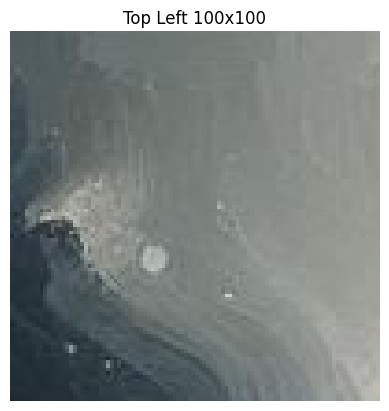

In [ ]:
# Convert image to NumPy array
img_array = np.array(image)

top_left = img_array[0:100, 0:100]

# Display it
plt.imshow(top_left)
plt.title("Top Left 100x100")
plt.axis("off")
plt.show()

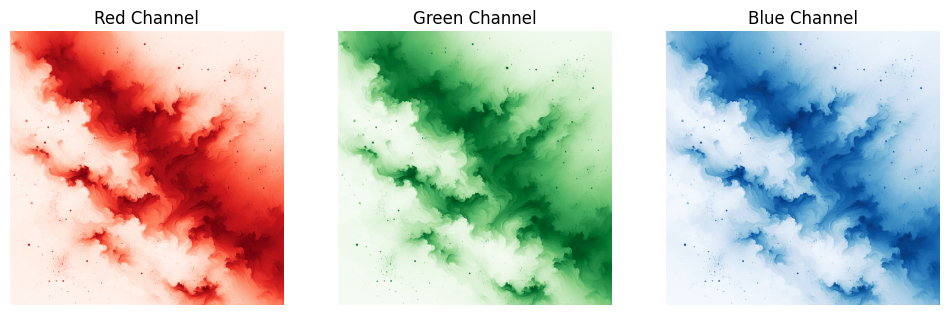

In [ ]:
#Perfect Bansal
# Separate channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Display each channel
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

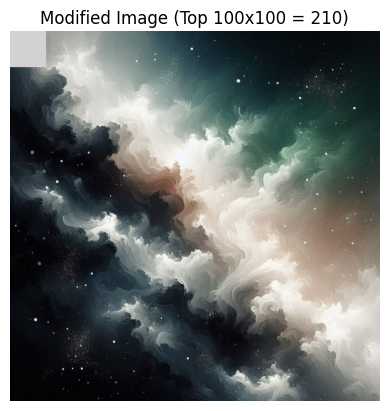

In [ ]:
# Make a copy so original image stays safe
modified = img_array.copy()
modified[0:100, 0:100] = 210

# Display modified image
plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

TASK 2

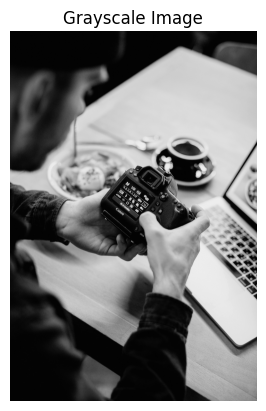

In [ ]:

image = Image.open("/content/drive/MyDrive/pexels-cottonbro-3584930.jpg").convert("L")
img_array = np.array(image)

# Display using matplotlib
plt.imshow(img_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

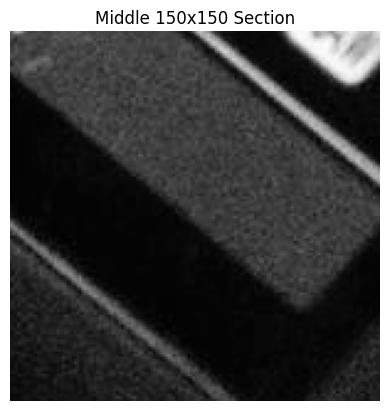

In [ ]:
#Extract Middle 150x150 Section
# Get image dimensions
height, width = img_array.shape

# Find center
center_y = height // 2
center_x = width // 2

# Extract 150x150 section (75 pixels each side)
cropped = img_array[
    center_y-75:center_y+75,
    center_x-75:center_x+75
]

# Display cropped image
plt.imshow(cropped, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

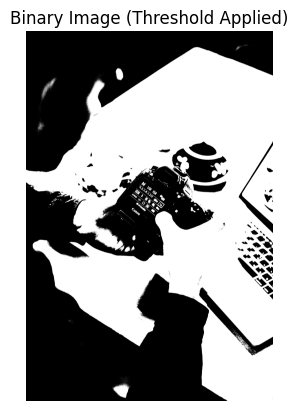

In [ ]:
#Apply Threshold (Binary Image)
# Create copy
threshold_img = img_array.copy()

# Apply threshold
threshold_img[threshold_img < 100] = 0
threshold_img[threshold_img >= 100] = 255

# Display result
plt.imshow(threshold_img, cmap="gray")
plt.title("Binary Image (Threshold Applied)")
plt.axis("off")
plt.show()

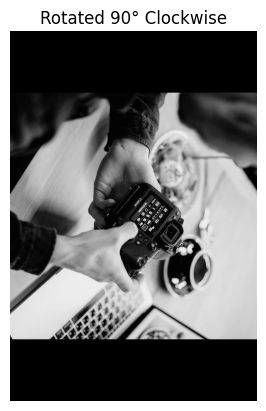

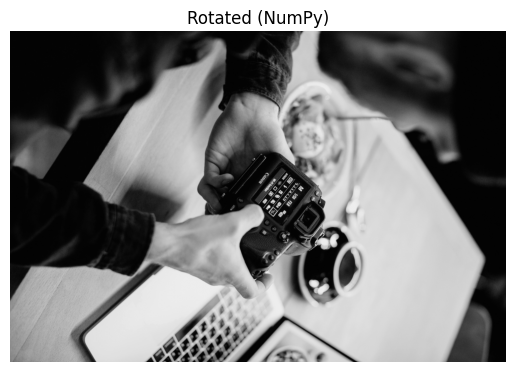

In [ ]:
# Rotate 90° Clockwise
# Method 1: Using Pillow
rotated = image.rotate(-90)  # negative = clockwise

plt.imshow(rotated, cmap="gray")
plt.title("Rotated 90° Clockwise")
plt.axis("off")
plt.show()
# Method 2: Using NumPy
rotated_np = np.rot90(img_array, -1)

plt.imshow(rotated_np, cmap="gray")
plt.title("Rotated (NumPy)")
plt.axis("off")
plt.show()

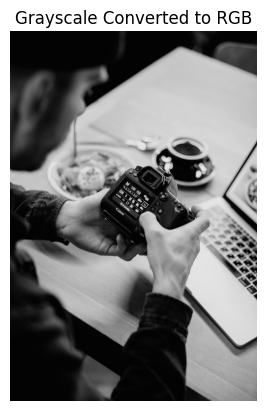

In [ ]:
#Graysclae to RGB
# Stack grayscale into 3 channels
rgb_image = np.stack((img_array,)*3, axis=-1)

# Display RGB image
plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

TASK 3

In [ ]:

image = Image.open("/content/drive/MyDrive/pexels-malcolmhill-11734225.jpg").convert("L")

# Convert to numpy array
img = np.array(image, dtype=float)

plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

print("Image shape:", img.shape)

In [ ]:
# Compute mean
mean = np.mean(img, axis=0)

# Center data
X_centered = img - mean

In [ ]:
# Covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (5558, 5558)


In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [ ]:
# Sort eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


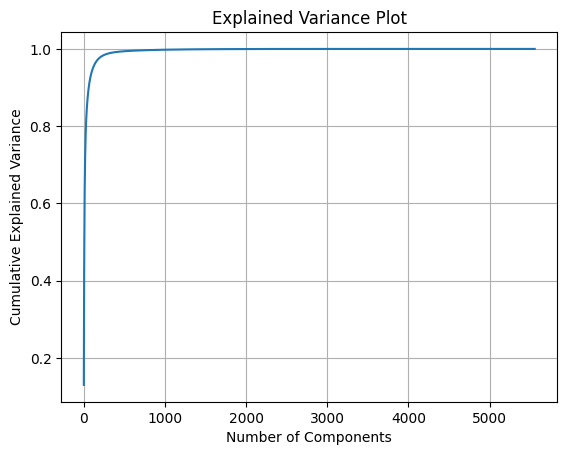

In [ ]:
# Explained variance ratio
explained_variance = eigenvalues / np.sum(eigenvalues)

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()
plt.show()

In [ ]:
def reconstruct_image(k):

    W = eigenvectors[:, :k]

    # Project data
    X_reduced = np.dot(X_centered, W)

    # Reconstruct
    X_reconstructed = np.dot(X_reduced, W.T) + mean

    return X_reconstructed




TypeError: Image data of dtype complex128 cannot be converted to float

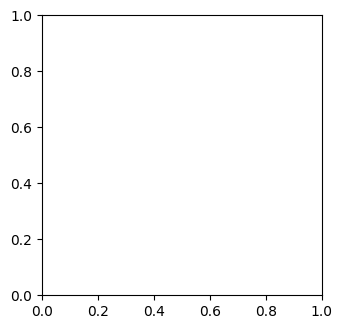

In [ ]:
k_values = [10, 30, 60, 100]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(k)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()